In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("../data/results.csv")
df.head()

,Unnamed: 0,Age,LogAmount,MovingAvg,MovingStd,LogTimeDiff,Hour,TransactionTypeEntropy,ChannelEntropy,CardTypeEntropy,...,CityEntropy,TransactionTypeFreq,ChannelFreq,CardTypeFreq,MerchandFreq,CountryFreq,CityFreq,scaledisoscores,scaledaescores,scaledsomscores
0,745,29,6.976077,6.149854,1.457936,2.142025,13,0.856967,0.997786,0.999945,...,0.224335,0.296247,0.296247,0.341823,0.126005,1.0,0.884718,0.215482,0.058282,0.064126
1,746,29,6.487105,6.179942,1.463149,2.807393,6,0.856967,0.997786,0.999945,...,0.224335,0.704150,0.224900,0.315930,0.127175,1.0,0.884873,0.158174,0.058174,0.063071
2,747,29,6.562359,6.124093,1.435917,3.509553,15,0.856967,0.997786,0.999945,...,0.224335,0.704545,0.225936,0.316845,0.128342,1.0,0.885027,0.174941,0.056761,0.102299
3,748,29,6.849225,6.430966,1.304665,0.902868,18,0.856967,0.997786,0.999945,...,0.224335,0.704940,0.249666,0.343124,0.138852,1.0,0.885180,0.144095,0.056083,0.066052
4,749,29,7.594638,6.981384,0.607484,2.228221,3,0.856967,0.997786,0.999945,...,0.224335,0.705333,0.230667,0.317333,0.140000,1.0,0.885333,0.237081,0.079401,0.124093


In [6]:
df['equalweightscore']=df[['scaledisoscores','scaledaescores','scaledsomscores']].mean(axis=1)

In [8]:
df['maxweightscore']=df[['scaledisoscores','scaledaescores','scaledsomscores']].max(axis=1)

In [9]:
wif,wae,wsom=0.5,0.3,0.2

df['weightedscores']=wif*df['scaledisoscores'] + wae*df['scaledaescores'] + wsom*df['scaledsomscores']

In [10]:
#ranks
df['rankiso']=df['scaledisoscores'].rank(method='average',ascending=False)
df['rankae']=df['scaledaescores'].rank(method='average',ascending=False)
df['ranksom']=df['scaledsomscores'].rank(method='average',ascending=False)

In [11]:
df['rankscore']=(1/df['rankiso'] + 1/df['rankae'] + 1/df['ranksom'])

In [12]:
#percentile ranks
df['prctiso']=df['scaledisoscores'].rank(pct=True)
df['prctae']=df['scaledaescores'].rank(pct=True)
df['prctsom']=df['scaledsomscores'].rank(pct=True)

In [13]:
df['rankprctscore']=df[['prctiso','prctae','prctsom']].mean(axis=1)

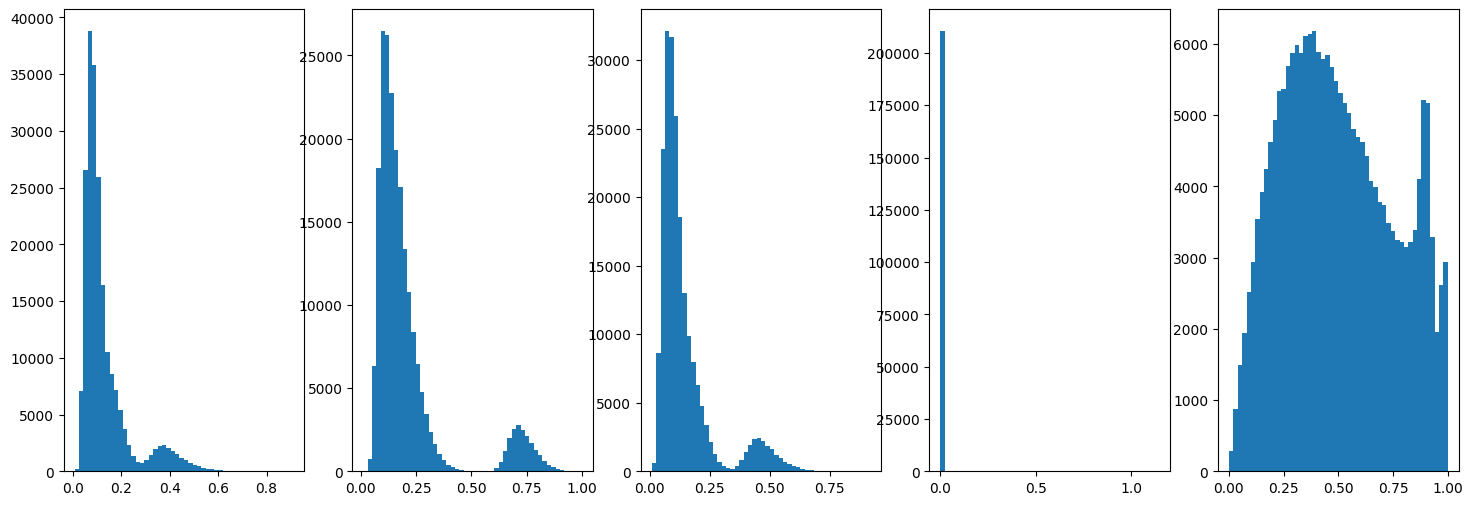

In [17]:
fig,axes=plt.subplots(nrows=1,ncols=5,figsize=(18,6))

axes[0].hist(df['equalweightscore'],bins=50)
axes[1].hist(df['maxweightscore'],bins=50)
axes[2].hist(df['weightedscores'],bins=50)
axes[3].hist(df['rankscore'],bins=50)
axes[4].hist(df['rankprctscore'],bins=50)

plt.show()

In [25]:
bases=['scaledisoscores','scaledaescores','scaledsomscores']
ensembles = ["equalweightscore", "maxweightscore", "weightedscores", "rankscore",'rankprctscore']

In [26]:
from scipy.stats import spearmanr

for ens in ensembles:
    print(f"\n--- {ens} ---")
    for base in bases:
        corr, _ = spearmanr(df[ens], df[base])
        print(f"{base}: {corr:.3f}")


--- equalweightscore ---
scaledisoscores: 0.969
scaledaescores: 0.726
scaledsomscores: 0.855

--- maxweightscore ---
scaledisoscores: 0.984
scaledaescores: 0.653
scaledsomscores: 0.814

--- weightedscores ---
scaledisoscores: 0.987
scaledaescores: 0.722
scaledsomscores: 0.811

--- rankscore ---
scaledisoscores: 0.924
scaledaescores: 0.803
scaledsomscores: 0.843

--- rankprctscore ---
scaledisoscores: 0.928
scaledaescores: 0.814
scaledsomscores: 0.860


In [27]:
def topk_set(df, col, q=0.99):
    return set(df[df[col] >= df[col].quantile(q)].index)

def jaccard(a, b):
    return len(a & b) / len(a | b)

for ens in ensembles:
    print(f"\n--- {ens} (Top 1%) ---")
    ens_set = topk_set(df, ens, 0.99)
    
    for base in bases:
        base_set = topk_set(df, base, 0.99)
        print(base, jaccard(ens_set, base_set))


--- equalweightscore (Top 1%) ---
scaledisoscores 0.5588452997779423
scaledaescores 0.5366654505654871
scaledsomscores 0.5216763005780347

--- maxweightscore (Top 1%) ---
scaledisoscores 0.9933743492664459
scaledaescores 0.38461538461538464
scaledsomscores 0.3653160453808752

--- weightedscores (Top 1%) ---
scaledisoscores 0.6156501726121979
scaledaescores 0.5710555762775084
scaledsomscores 0.4599653379549393

--- rankscore (Top 1%) ---
scaledisoscores 0.5876366377685639
scaledaescores 0.488339222614841
scaledsomscores 0.5283018867924528

--- rankprctscore (Top 1%) ---
scaledisoscores 0.5172910662824207
scaledaescores 0.5383491599707816
scaledsomscores 0.4292500848320326


In [28]:
def topk_set(df, col, q=0.95):
    return set(df[df[col] >= df[col].quantile(q)].index)

def jaccard(a, b):
    return len(a & b) / len(a | b)

for ens in ensembles:
    print(f"\n--- {ens} (Top 5%) ---")
    ens_set = topk_set(df, ens, 0.95)
    
    for base in bases:
        base_set = topk_set(df, base, 0.95)
        print(base, jaccard(ens_set, base_set))


--- equalweightscore (Top 5%) ---
scaledisoscores 0.7710296096904441
scaledaescores 0.39356632247815726
scaledsomscores 0.7257377049180328

--- maxweightscore (Top 5%) ---
scaledisoscores 1.0
scaledaescores 0.35692188708430006
scaledsomscores 0.6109878338051878

--- weightedscores (Top 5%) ---
scaledisoscores 0.8204928664072633
scaledaescores 0.39745121465551575
scaledsomscores 0.6825701270678495

--- rankscore (Top 5%) ---
scaledisoscores 0.7069888114155991
scaledaescores 0.4826760563380282
scaledsomscores 0.6615894562386552

--- rankprctscore (Top 5%) ---
scaledisoscores 0.6772882976180993
scaledaescores 0.48086932057954707
scaledsomscores 0.6114342568498393
